# Vineyard Wind -- Cluster AEP and Wake Effect Analysis

Imports and shared config from the Risk_Investigation pipeline.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import windIO

from py_wake.wind_farm_models import PropagateDownwind
from py_wake.deficit_models import NOJDeficit
from py_wake.literature.turbopark import Nygaard_2022
from py_wake.literature.gaussian_models import Blondel_Cathelain_2020
from py_wake.turbulence_models import CrespoHernandez
from py_wake.superposition_models import SquaredSum
from py_wake.flow_map import HorizontalGrid

from config import ERA5_DIR, SITE_YEAR, ALL_YEARS, SYSTEM_YAML, FOCUS_FARM, SIM_WD, SIM_WS, FIGURES_DIR
from site_builder import build_site
from cluster_layout import load_cluster, BOUNDARY_NAMES
from aep_simulation import build_turbine_types, construct_wfm, compute_neighbor_aep, _combined_arrays


Dark theme for every plot in this notebook.

In [2]:
plt.style.use("dark_background")
plt.rcParams["figure.facecolor"] = "#1e1e1e"
plt.rcParams["axes.facecolor"] = "#1e1e1e"
plt.rcParams["savefig.facecolor"] = "#1e1e1e"


Small helper to overlay lease boundaries on a layout plot.

In [3]:
def get_boundaries(names):
    system_dat = windIO.load_yaml(SYSTEM_YAML)
    polygons = system_dat["site"]["boundaries"]["polygons"]
    return {n: (p["x"], p["y"]) for n, p in zip(BOUNDARY_NAMES, polygons) if n in names}


def plot_boundaries(ax, names):
    for name, (bx, by) in get_boundaries(names).items():
        ax.plot(np.array(bx) / 1000, np.array(by) / 1000, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)


## 1. Reference Year and Wake Map -- Real Farms Only
Build one reference year's site (ERA5 2023), a 12-sector wind rose, and the cluster layout.

In [4]:
site, summary = build_site(ERA5_DIR / f"era5_{SITE_YEAR}.grib")
farms = load_cluster()
real_farms = [f for f in farms if not f["is_synthetic"]]

dominant_wd = SIM_WD[int(np.argmax(summary["freq"]))]
print(f"Reference year {SITE_YEAR}: mean speed {summary['mean_speed']:.2f} m/s, dominant direction {dominant_wd} deg")


Ignoring index file '/Users/brunoboer/Desktop/Advanced_Optimizer/Project_Monte_Carlo/era5_vineyard/era5_2023.grib.5b7b6.idx' incompatible with GRIB file


Reference year 2023: mean speed 8.53 m/s, dominant direction 240 deg


Build one combined turbine set and wake model for the whole notebook's fixed-model sections.

In [5]:
multi_turbines, type_by_farm = build_turbine_types(farms)
wfm = construct_wfm(site, multi_turbines)


Wake map with only the real, currently-existing farms (Vineyard, Revolution, South Fork, Sunrise South).

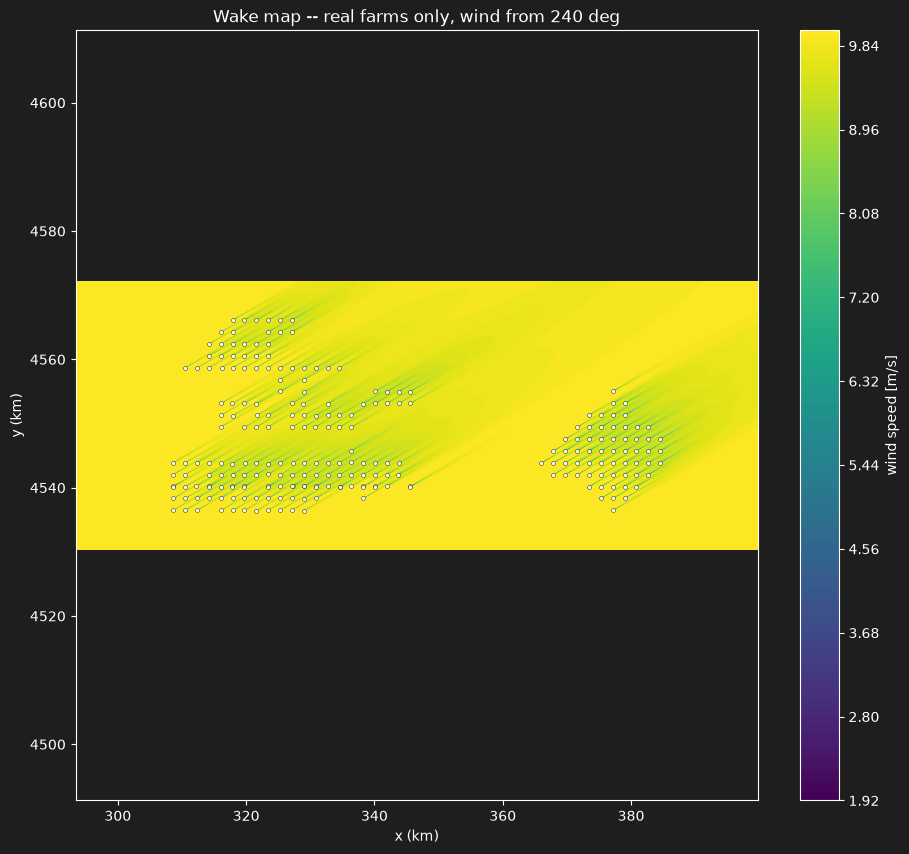

In [6]:
_, x_real, y_real, type_real = _combined_arrays(real_farms, type_by_farm, FOCUS_FARM)
sim_real_snap = wfm(x_real, y_real, type=type_real, wd=[dominant_wd], ws=[10])
fmap_real = sim_real_snap.flow_map(grid=HorizontalGrid(resolution=400))

fig, ax = plt.subplots(figsize=(11, 10))
fmap_real.plot_wake_map(ax=ax, cmap="viridis", normalize_with=1000, plot_windturbines=False)
ax.scatter(np.array(x_real) / 1000, np.array(y_real) / 1000, s=8, color="white", edgecolor="black", linewidth=0.3)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title(f"Wake map -- real farms only, wind from {dominant_wd} deg")
fig.savefig(FIGURES_DIR / "nb_wake_map_real_farms.png", dpi=180, bbox_inches="tight")
plt.show()


## 2. Wake Map -- Fully Populated Cluster
Add the synthetic-fill farms and render the same wind direction over the whole cluster.

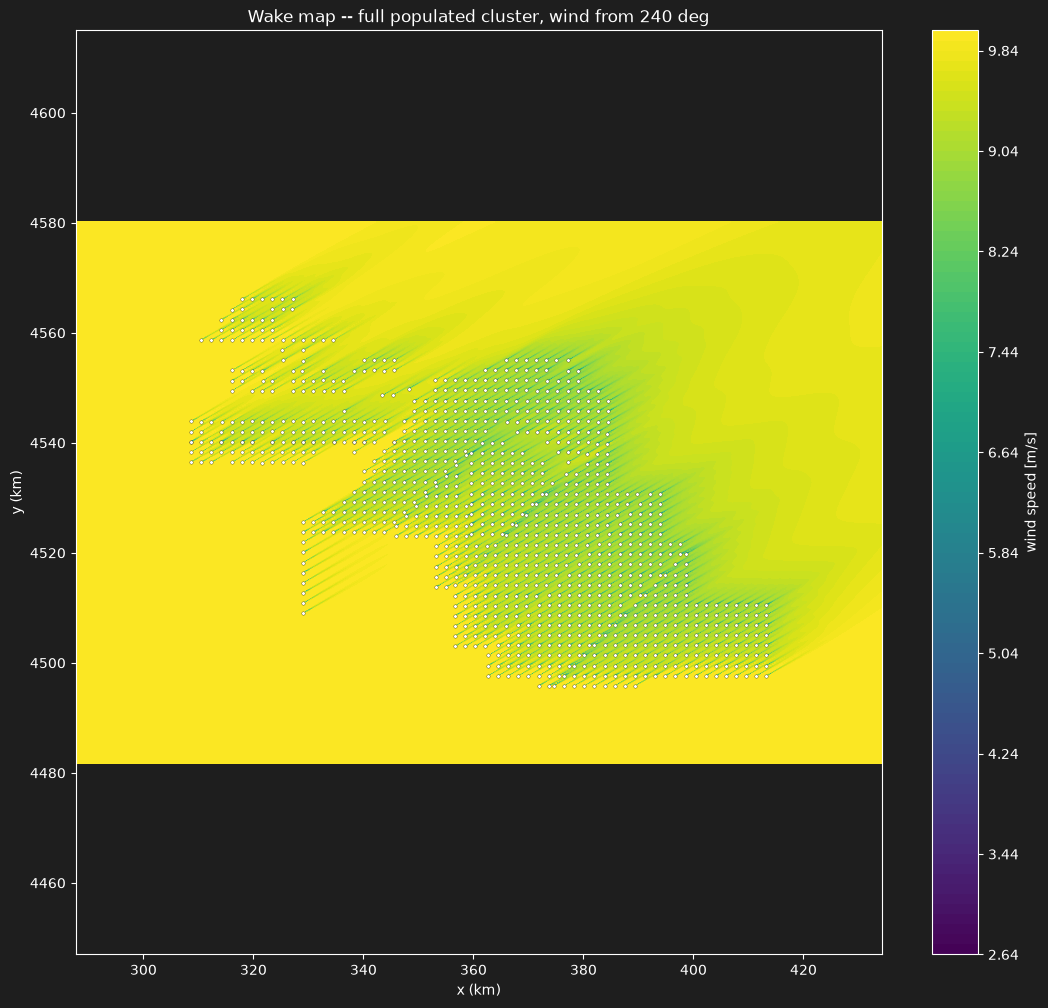

In [7]:
_, x_full, y_full, type_full = _combined_arrays(farms, type_by_farm, FOCUS_FARM)
sim_full_snap = wfm(x_full, y_full, type=type_full, wd=[dominant_wd], ws=[10])
fmap_full = sim_full_snap.flow_map(grid=HorizontalGrid(resolution=400))

fig, ax = plt.subplots(figsize=(13, 12))
fmap_full.plot_wake_map(ax=ax, cmap="viridis", normalize_with=1000, plot_windturbines=False)
ax.scatter(np.array(x_full) / 1000, np.array(y_full) / 1000, s=6, color="white", edgecolor="black", linewidth=0.2)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title(f"Wake map -- full populated cluster, wind from {dominant_wd} deg")
fig.savefig(FIGURES_DIR / "nb_wake_map_full_cluster.png", dpi=180, bbox_inches="tight")
plt.show()


## 3. AEP -- Real Neighbors Scenario
Vineyard Wind's AEP with only the real neighboring farms present.

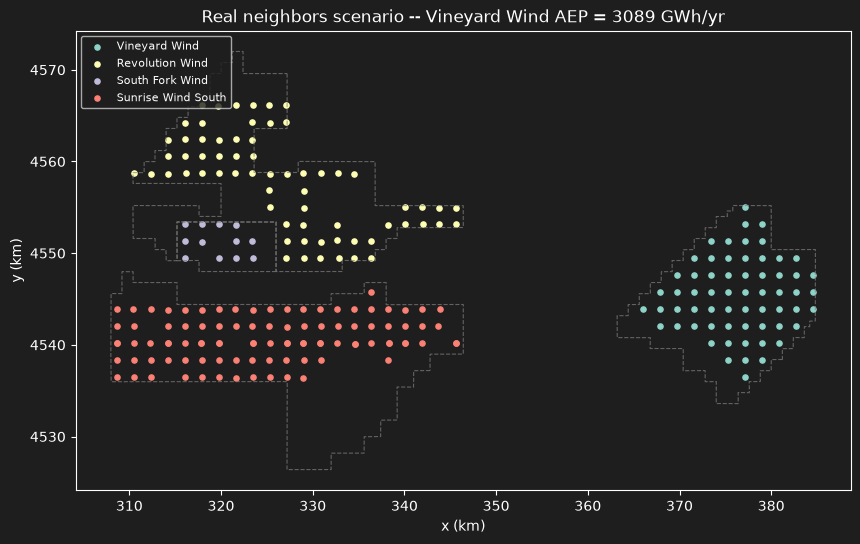

In [8]:
real_aep, x_real, y_real, type_real = compute_neighbor_aep(wfm, real_farms, type_by_farm, FOCUS_FARM)

fig, ax = plt.subplots(figsize=(10, 9))
for f in real_farms:
    ax.scatter(f["x"] / 1000, f["y"] / 1000, s=14, label=f["name"])
plot_boundaries(ax, [f["name"] for f in real_farms])
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_aspect("equal")
ax.legend(fontsize=8, loc="upper left")
ax.set_title(f"Real neighbors scenario -- Vineyard Wind AEP = {real_aep:.0f} GWh/yr")
fig.savefig(FIGURES_DIR / "nb_layout_real_neighbors.png", dpi=180, bbox_inches="tight")
plt.show()


## 4. AEP -- Fully Populated Cluster
Vineyard Wind's AEP with the whole cluster (real + synthetic) present.

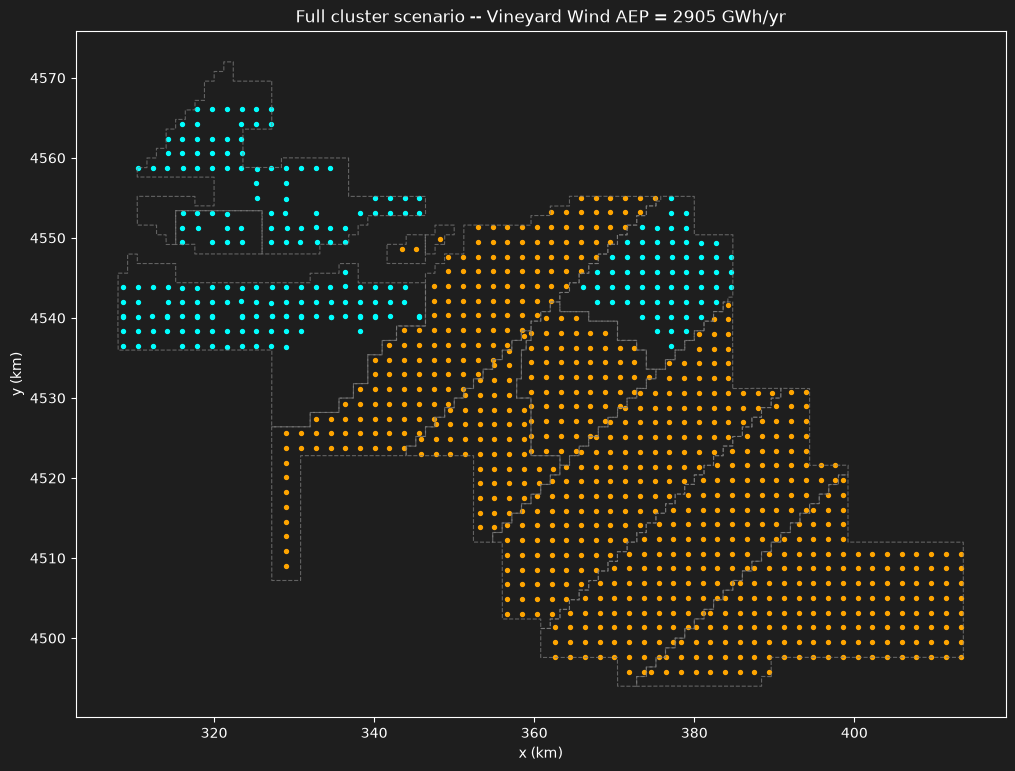

In [9]:
full_aep, x_full, y_full, type_full = compute_neighbor_aep(wfm, farms, type_by_farm, FOCUS_FARM)

fig, ax = plt.subplots(figsize=(12, 11))
for f in farms:
    if f["n_turbines"] == 0:
        continue
    color = "orange" if f["is_synthetic"] else "cyan"
    ax.scatter(f["x"] / 1000, f["y"] / 1000, s=8, color=color)
plot_boundaries(ax, [f["name"] for f in farms])
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_aspect("equal")
ax.set_title(f"Full cluster scenario -- Vineyard Wind AEP = {full_aep:.0f} GWh/yr")
fig.savefig(FIGURES_DIR / "nb_layout_full_cluster.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. Wake Model Sensitivity (Fixed Year)
Three deficit models, each with its literature-matched superposition, same year and layout.

In [ ]:
# Each entry is a builder (site, turbines) -> wfm, using PyWake's own literature-validated
# wrappers (py_wake.literature) instead of bare deficit models, so the comparison matches
# the calibration used in the benchmark papers (Rodrigues & Moura 2025; Moura & Rodrigues 2025).
WAKE_MODELS = {
    "Nygaard_TurboGaussian": lambda s, t: Nygaard_2022(s, t),
    "SuperGaussian": lambda s, t: Blondel_Cathelain_2020(s, t, turbulenceModel=CrespoHernandez()),
    "NOJ": lambda s, t: PropagateDownwind(s, t, wake_deficitModel=NOJDeficit(), superpositionModel=SquaredSum()),
}


Run the full-cluster AEP under each model and plot the layout with its AEP.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, (name, build_wfm) in zip(axes, WAKE_MODELS.items()):
    wfm_m = build_wfm(site, multi_turbines)
    aep_m, x_f, y_f, _ = compute_neighbor_aep(wfm_m, farms, type_by_farm, FOCUS_FARM)

    for f in farms:
        if f["n_turbines"] == 0:
            continue
        color = "orange" if f["is_synthetic"] else "cyan"
        ax.scatter(f["x"] / 1000, f["y"] / 1000, s=5, color=color)
    ax.set_aspect("equal")
    ax.set_title(f"{name}\nAEP = {aep_m:.0f} GWh/yr")

fig.suptitle(f"Wake model sensitivity -- full cluster, {SITE_YEAR}")
fig.savefig(FIGURES_DIR / "nb_wake_model_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Annual Variability Across Wake Models
Sweep all 24 ERA5 years for each wake model, comparing real neighbors vs. full cluster AEP.

In [ ]:
rows = []
for model_name, build_wfm in WAKE_MODELS.items():
    for year in ALL_YEARS:
        site_y, _ = build_site(ERA5_DIR / f"era5_{year}.grib")
        wfm_y = build_wfm(site_y, multi_turbines)
        real_y, *_ = compute_neighbor_aep(wfm_y, real_farms, type_by_farm, FOCUS_FARM)
        full_y, *_ = compute_neighbor_aep(wfm_y, farms, type_by_farm, FOCUS_FARM)

        rows.append(dict(
            year=year, model=model_name,
            real_neighbors_aep_gwh=real_y, full_cluster_aep_gwh=full_y,
            cluster_impact_pct=(real_y - full_y) / real_y * 100,
        ))
    print(f"{model_name} done")

df6 = pd.DataFrame(rows)
df6.to_csv("results/wake_model_annual_sweep.csv", index=False)


AEP year by year, one panel per wake model.

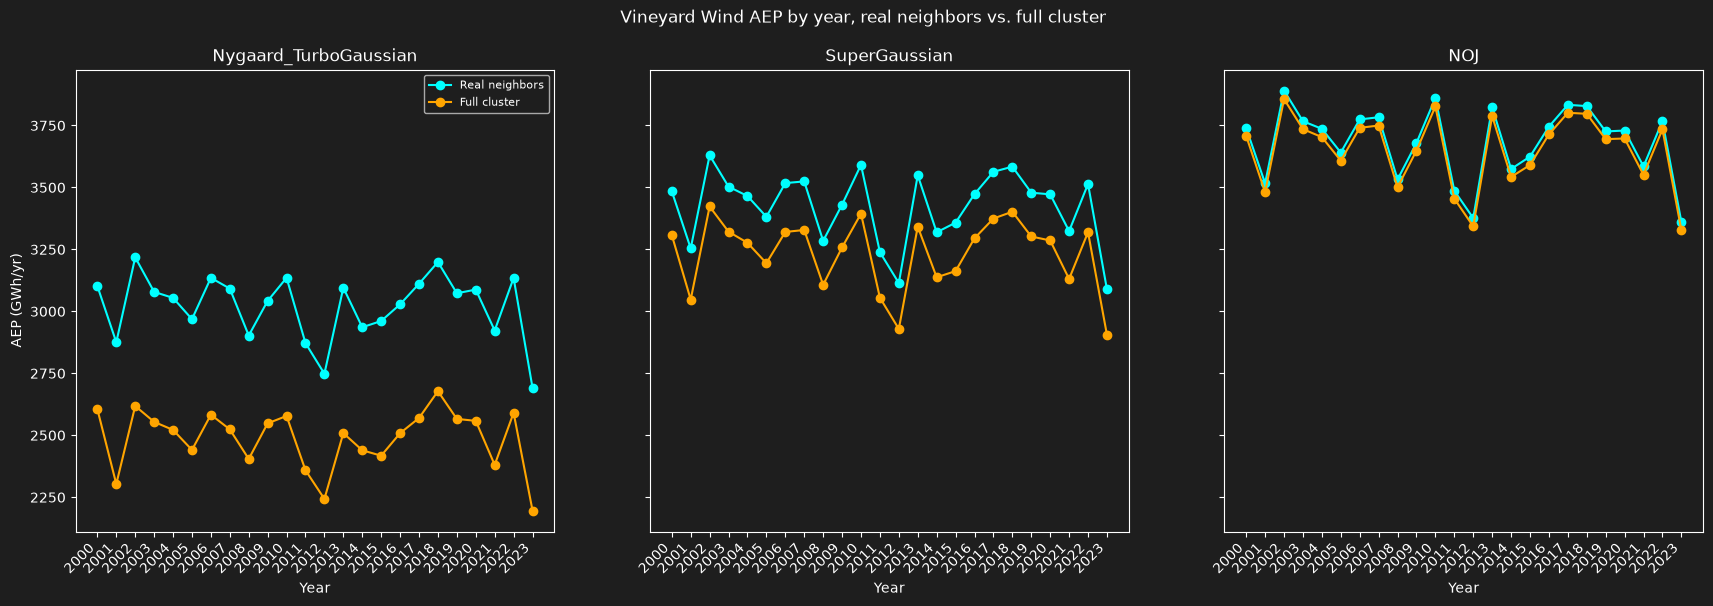

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
for ax, model_name in zip(axes, WAKE_MODELS):
    sub = df6[df6["model"] == model_name]
    ax.plot(sub["year"], sub["real_neighbors_aep_gwh"], "o-", color="cyan", label="Real neighbors")
    ax.plot(sub["year"], sub["full_cluster_aep_gwh"], "o-", color="orange", label="Full cluster")
    ax.set_title(model_name)
    ax.set_xlabel("Year")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
axes[0].set_ylabel("AEP (GWh/yr)")
axes[0].legend(fontsize=8)
fig.suptitle("Vineyard Wind AEP by year, real neighbors vs. full cluster")
fig.savefig(FIGURES_DIR / "nb_annual_aep_by_model.png", dpi=180, bbox_inches="tight")
plt.show()


Cluster impact (real neighbors vs. full cluster) by year, one line per model -- shows which model is most sensitive to wind rose variation.

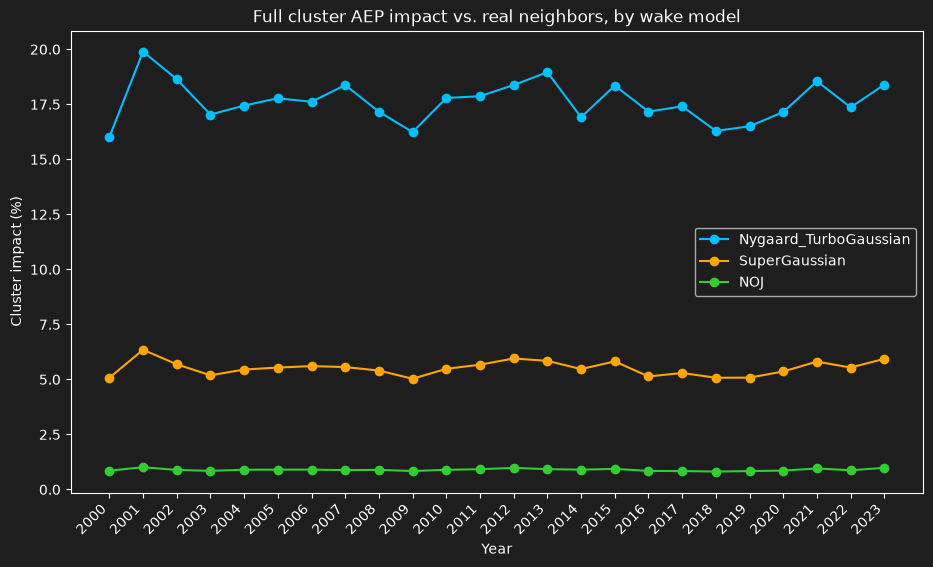

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = {"Nygaard_TurboGaussian": "deepskyblue", "SuperGaussian": "orange", "NOJ": "limegreen"}
for model_name in WAKE_MODELS:
    sub = df6[df6["model"] == model_name]
    ax.plot(sub["year"], sub["cluster_impact_pct"], "o-", color=colors[model_name], label=model_name)
ax.set_xlabel("Year")
ax.set_ylabel("Cluster impact (%)")
ax.set_title("Full cluster AEP impact vs. real neighbors, by wake model")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.savefig(FIGURES_DIR / "nb_cluster_impact_by_model.png", dpi=180, bbox_inches="tight")
plt.show()


Spread of the cluster impact per model across the 24 years -- the widest box is the most sensitive model.

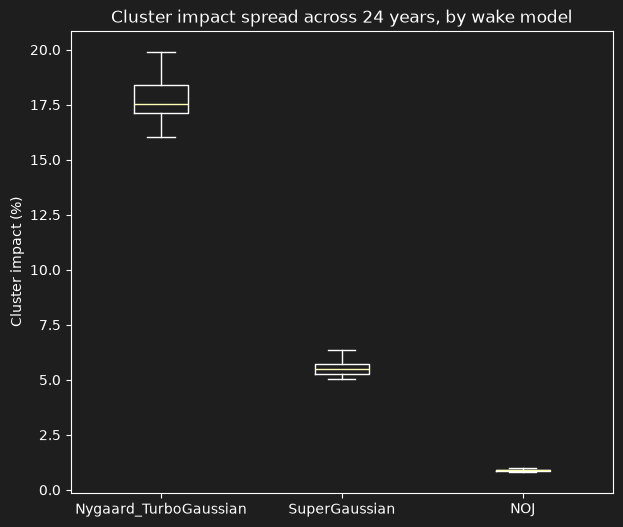

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
data = [df6[df6["model"] == m]["cluster_impact_pct"] for m in WAKE_MODELS]
ax.boxplot(data, tick_labels=list(WAKE_MODELS.keys()))
ax.set_ylabel("Cluster impact (%)")
ax.set_title("Cluster impact spread across 24 years, by wake model")
fig.savefig(FIGURES_DIR / "nb_cluster_impact_spread.png", dpi=180, bbox_inches="tight")
plt.show()
